In [75]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import pandas as pd
from data.stock_returns import fetch_stock_data, cache_all_stock_data, construct_forward_backward_returns_adtv
from data.data_utils import load_raw_stock_transactions, load_feature_set, load_raw_congressional_transactions, load_standardized_feature_set
from src.models.deep_sad import run_deep_sad
import yfinance as yf
from sklearn.ensemble import IsolationForest
from src.models.isolation_forest import run_isolation_forest, get_isolation_model
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from src.models.deep_svdd import get_anomaly_scores, run_deep_svdd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Isolation Forest

In [76]:
df = run_isolation_forest()
raw_df = load_feature_set()
df = raw_df.join(df[["anomaly_label", "anomaly_score"]])

for i in [1, 5, 15, 30]:
    df.loc[:, f"directional_returns_after_{i}d"] = df[f"returns_after_{i}d"] * df["direction"]

for i in [1, 5, 15, 30]: 
    df[f"{i}d_pnl"] = ((1 + df[f"directional_returns_after_{i}d"]) * df["amount"]) - df["amount"]

flagged_df = df.loc[df["anomaly_label"] == -1]
normal_df = df.loc[df["anomaly_label"] == 1]

Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid


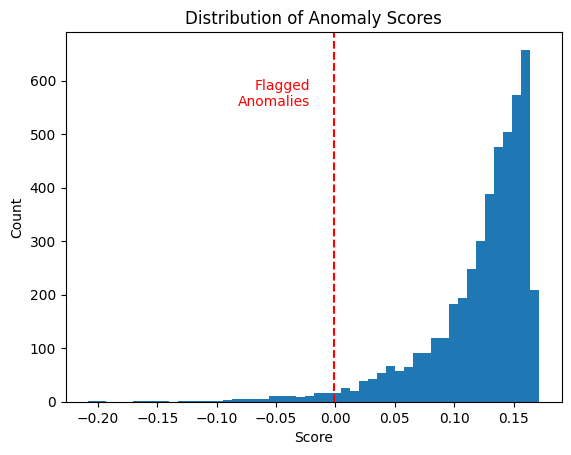

In [77]:
plt.hist(df['anomaly_score'], bins=50)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Score')
plt.ylabel('Count')
threshold = flagged_df["anomaly_score"].max()
plt.text(threshold-0.02, plt.ylim()[1]*0.8, 'Flagged\nAnomalies', color='red', ha='right')
plt.axvline(threshold, color='red', linestyle='--')
plt.show()

In [78]:
for i in [1, 5, 15, 30]:
    t_stat, p_value = ttest_ind(
        flagged_df[f"directional_returns_after_{i}d"], 
        normal_df[f"directional_returns_after_{i}d"], 
        equal_var=False
    )
    print(f'Returns after {i} days: {t_stat=}, {p_value=}')

Returns after 1 days: t_stat=np.float64(-2.530972421340475), p_value=np.float64(0.012583302825922602)
Returns after 5 days: t_stat=np.float64(0.14967142807288675), p_value=np.float64(0.8812588573012843)
Returns after 15 days: t_stat=np.float64(0.4778864078195786), p_value=np.float64(0.6335431190869651)
Returns after 30 days: t_stat=np.float64(0.23179407236213134), p_value=np.float64(0.8170661195649986)


In [79]:
for i in [5, 15, 30]:
    t_stat, p_value = ttest_ind(
        flagged_df[f"adtv_after_{i}d"], 
        normal_df[f"adtv_after_{i}d"], 
        equal_var=False
    )
    print(f'ADTV after {i} days: {t_stat=}, {p_value=}')

ADTV after 5 days: t_stat=np.float64(5.753143757072807), p_value=np.float64(6.10723570454047e-08)
ADTV after 15 days: t_stat=np.float64(7.112681759050969), p_value=np.float64(7.067530742628489e-11)
ADTV after 30 days: t_stat=np.float64(8.795454088617829), p_value=np.float64(7.496992724905852e-15)


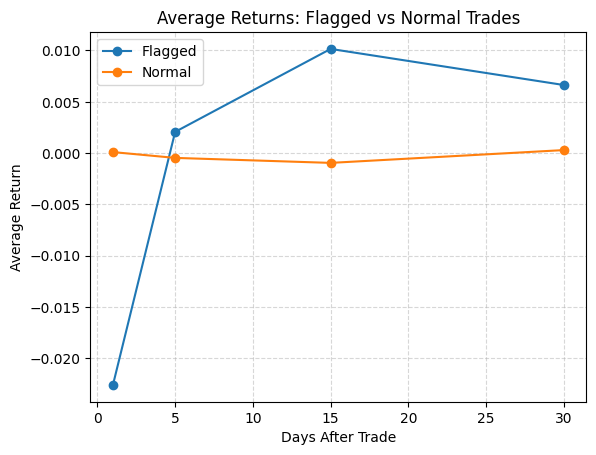

In [80]:
horizons = [1, 5, 15, 30]
flagged_means = []
normal_means = []

for h in horizons:
    flagged_means.append(df.loc[df["anomaly_label"] == -1, f'directional_returns_after_{h}d'].mean())
    normal_means.append(df.loc[df["anomaly_label"] == 1, f'directional_returns_after_{h}d'].mean())

plt.plot(horizons, flagged_means, marker='o', label='Flagged')
plt.plot(horizons, normal_means, marker='o', label='Normal')
plt.xlabel('Days After Trade')
plt.ylabel('Average Return')
plt.title('Average Returns: Flagged vs Normal Trades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

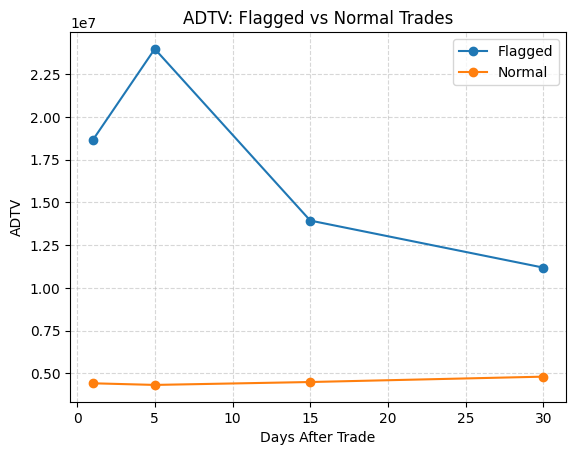

In [81]:
horizons = [1, 5, 15, 30]
flagged_means = []
normal_means = []

for h in horizons:
    flagged_means.append(df.loc[df["anomaly_label"] == -1, f'adtv_after_{h}d'].mean())
    normal_means.append(df.loc[df["anomaly_label"] == 1, f'adtv_after_{h}d'].mean())

plt.plot(horizons, flagged_means, marker='o', label='Flagged')
plt.plot(horizons, normal_means, marker='o', label='Normal')
plt.xlabel('Days After Trade')
plt.ylabel('ADTV')
plt.title('ADTV: Flagged vs Normal Trades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Text(0.5, 1.0, '30-Day Return Distribution')

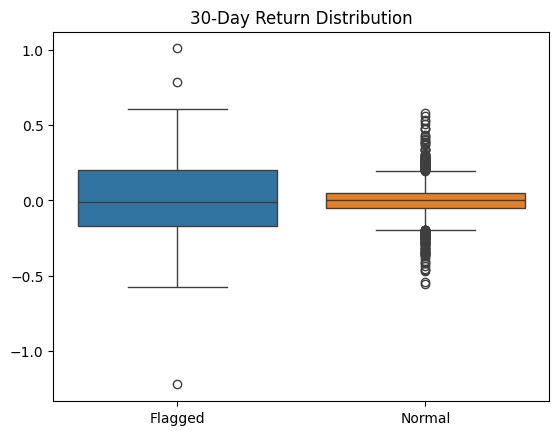

In [82]:
plot_df = pd.concat(
    [
        flagged_df["directional_returns_after_30d"], 
        normal_df["directional_returns_after_30d"]
    ], 
    ignore_index=True,
    axis=1
)

sns.boxplot(data=plot_df)

plt.xticks([0, 1], ['Flagged', 'Normal'])
plt.title('30-Day Return Distribution')

In [83]:
flagged_df["15d_pnl"].mean(), normal_df["15d_pnl"].mean()

(np.float64(-1453.817597038418), np.float64(159.72194775029692))

In [84]:
df.xs("David Perdue", level='senator').sort_values("15d_pnl", ascending=False)[["amount", "anomaly_score", "anomaly_label", "30d_pnl"]].head(10)

amount  anomaly_score  anomaly_label        30d_pnl
date       ticker                                                       
2020-03-18 CDLX    350001.0      -0.113061             -1  100063.279255
2020-04-14 URBN    175000.5       0.037345              1    6766.216851
2018-11-26 HBI     175000.5       0.123707              1   18340.831878
2018-12-27 HBI     175000.5       0.067631              1   70951.723492
2020-04-14 BRK-B   207501.0       0.119431              1   22144.523102
2020-02-27 CZR      24001.5       0.006537              1   13861.396478
2019-10-11 LGF-B    75000.5       0.102745              1    5973.617026
2020-04-14 DIS     272502.0       0.118755              1  -20880.940585
           GM      175000.5       0.038608              1  -24457.106057
2015-08-12 LNT     375000.5       0.098596              1   -2737.996672

In [85]:
df.xs("Kelly Loeffler", level='senator').sort_values("15d_pnl", ascending=False)[["amount", "anomaly_score", "anomaly_label", "30d_pnl"]].head(10)

amount  anomaly_score  anomaly_label       30d_pnl
date       ticker                                                        
2020-02-18 ICE     15000000.5       0.075751              1  1.087297e+06
2020-05-20 ICE     15000000.5       0.072841              1  9.855400e+05
2020-03-18 AIZ       375000.5      -0.063995             -1  3.891696e+04
2020-04-14 HIG       350001.0       0.045446              1  4.098391e+04
2020-02-14 XOM       375000.5       0.078270              1  6.048206e+04
2020-03-20 WDC       175000.5      -0.090007             -1  9.620363e+03
           PRU       175000.5      -0.006806             -1  2.693268e+04
2020-04-07 VZ        375000.5       0.042270              1  5.903838e+04
2020-04-14 STT       550001.0       0.079746              1  4.409580e+03
2020-02-12 EEFT      175000.5       0.045232              1  2.542659e+04

# Deep SVDD

In [86]:
df = run_deep_svdd(quantile=.95)
raw_df = load_feature_set()
df = raw_df.join(df[["anomaly_label", "anomaly_score"]])

for i in [1, 5, 15, 30]:
    df.loc[:, f"directional_returns_after_{i}d"] = df[f"returns_after_{i}d"] * df["direction"]

for i in [1, 5, 15, 30]: 
    df[f"{i}d_pnl"] = ((1 + df[f"directional_returns_after_{i}d"]) * df["amount"]) - df["amount"]

flagged_df = df.loc[df["anomaly_label"] == -1]
normal_df = df.loc[df["anomaly_label"] == 1]

Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Epoch 10/300, Loss: 0.029498929948839424
Epoch 20/300, Loss: 0.013807281201118475
Epoch 30/300, Loss: 0.0034557225913039013
Epoch 40/300, Loss: 0.006858010046751787
Epoch 50/300, Loss: 0.0011205082573475036
Epoch 60/300, Loss: 0.0016246084237474413
Epoch 70/300, Loss: 0.0008743420448186106
Epoch 80/300, Loss: 0.00021342964798462424
Epoch 90/300, Loss: 0.0005593408885482086
Epoch 100/300, Loss: 0.0001989631700033062
Epoch 110/300, Loss: 0.00010904028589072979
Epoch 120/300, Loss: 4.276006980533516e-05
Epoch 130/300, Loss: 0.0004862956303528236
Epoch 140/300, Loss: 8.654391301474352e-06
Epoch 150/300, Loss: 1.4100518904479654e-05
Epoch 160/300, Loss: 1.2923591586283305e-05
Epoch 170/300, Loss: 9.557891305638343e-06
Epoch 180/300, Loss: 8.13915255100897e-06
Epoch 190/300, Loss: 1.5384071749957138e-06
Epoch 200/300, Loss: 1.75601150589709e-06
Epoch 210/300, Loss: 1.3252831359822054e-06
Epoch 220/300, Loss: 4.7469050593470187e-07
Epoch 230/300, Loss: 2.4196985

<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid


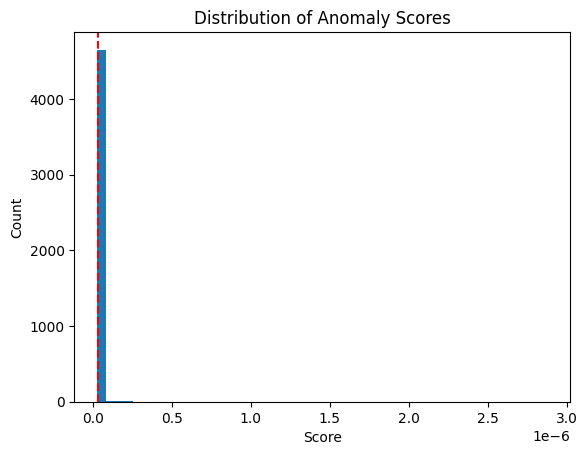

In [87]:
import numpy as np
plt.hist(df['anomaly_score'], bins=50)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Score')
plt.ylabel('Count')
threshold = flagged_df["anomaly_score"].min()
# plt.text(threshold+0.5, plt.ylim()[1]*0.8, 'Flagged\nAnomalies', color='red', ha='right')
plt.axvline(threshold, color='red', linestyle='--')
plt.show()

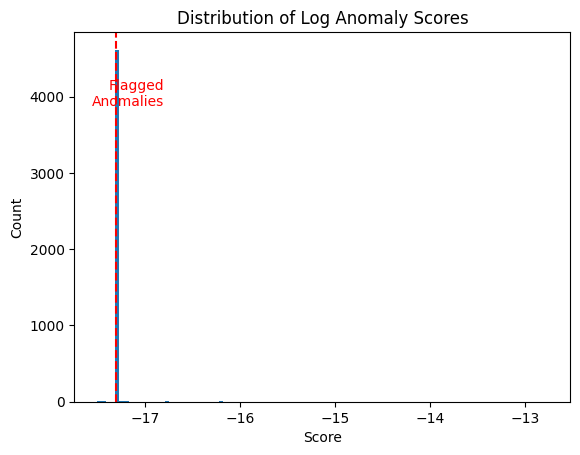

In [88]:
df["log_anomaly_score"] = np.log(df["anomaly_score"])

import numpy as np
plt.hist(df['log_anomaly_score'], bins=100)
plt.title('Distribution of Log Anomaly Scores')
plt.xlabel('Score')
plt.ylabel('Count')
threshold = df.loc[df["anomaly_label"] == -1, "log_anomaly_score"].min()
plt.text(threshold+0.5, plt.ylim()[1]*0.8, 'Flagged\nAnomalies', color='red', ha='right')
plt.axvline(threshold, color='red', linestyle='--')
plt.show()

In [89]:
for i in [1, 5, 15, 30]:
    t_stat, p_value = ttest_ind(
        flagged_df[f"directional_returns_after_{i}d"], 
        normal_df[f"directional_returns_after_{i}d"], 
        equal_var=False
    )
    print(f'Returns after {i} days: {t_stat=}, {p_value=}')

Returns after 1 days: t_stat=np.float64(0.7098859212413511), p_value=np.float64(0.48092167603179947)
Returns after 5 days: t_stat=np.float64(0.01556578000216909), p_value=np.float64(0.9876417385375049)
Returns after 15 days: t_stat=np.float64(-0.9019441761707052), p_value=np.float64(0.3713006229449157)
Returns after 30 days: t_stat=np.float64(-0.19461832851511468), p_value=np.float64(0.8464593236814622)


In [90]:
for i in [5, 15, 30]:
    t_stat, p_value = ttest_ind(
        flagged_df[f"adtv_after_{i}d"], 
        normal_df[f"adtv_after_{i}d"], 
        equal_var=False
    )
    print(f'ADTV after {i} days: {t_stat=}, {p_value=}')

ADTV after 5 days: t_stat=np.float64(-1.548013162133269), p_value=np.float64(0.12727947401917303)
ADTV after 15 days: t_stat=np.float64(-0.7573362830360075), p_value=np.float64(0.4523055450566461)
ADTV after 30 days: t_stat=np.float64(-0.4195150991219365), p_value=np.float64(0.6766007599869115)


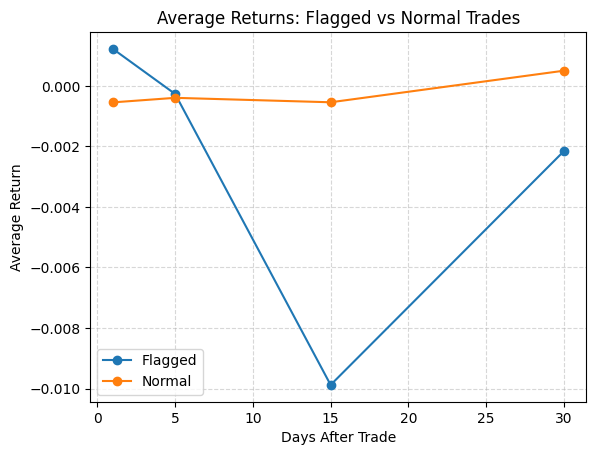

In [91]:
horizons = [1, 5, 15, 30]
flagged_means = []
normal_means = []

for h in horizons:
    flagged_means.append(df.loc[df["anomaly_label"] == -1, f'directional_returns_after_{h}d'].mean())
    normal_means.append(df.loc[df["anomaly_label"] == 1, f'directional_returns_after_{h}d'].mean())

plt.plot(horizons, flagged_means, marker='o', label='Flagged')
plt.plot(horizons, normal_means, marker='o', label='Normal')
plt.xlabel('Days After Trade')
plt.ylabel('Average Return')
plt.title('Average Returns: Flagged vs Normal Trades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

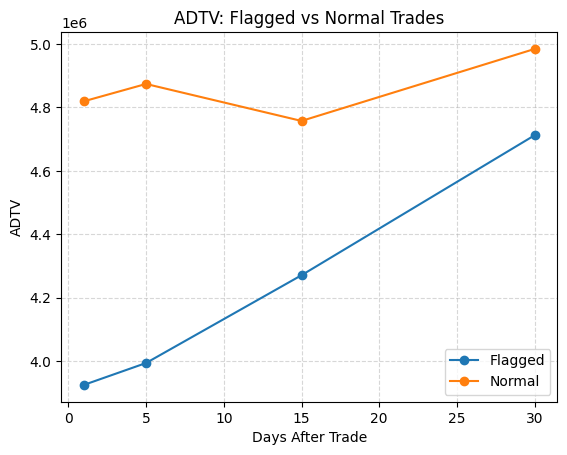

In [92]:
horizons = [1, 5, 15, 30]
flagged_means = []
normal_means = []

for h in horizons:
    flagged_means.append(df.loc[df["anomaly_label"] == -1, f'adtv_after_{h}d'].mean())
    normal_means.append(df.loc[df["anomaly_label"] == 1, f'adtv_after_{h}d'].mean())

plt.plot(horizons, flagged_means, marker='o', label='Flagged')
plt.plot(horizons, normal_means, marker='o', label='Normal')
plt.xlabel('Days After Trade')
plt.ylabel('ADTV')
plt.title('ADTV: Flagged vs Normal Trades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Text(0.5, 1.0, '30-Day Return Distribution')

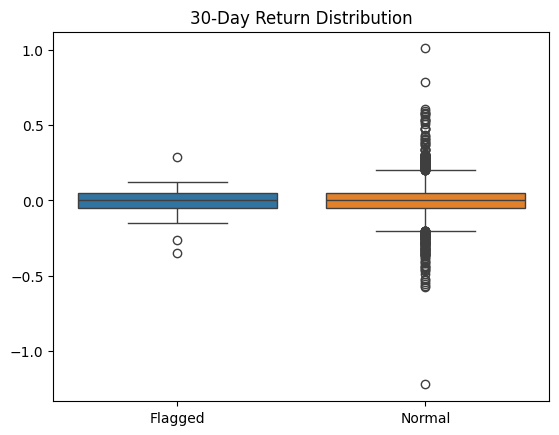

In [93]:
plot_df = pd.concat(
    [
        flagged_df["directional_returns_after_30d"], 
        normal_df["directional_returns_after_30d"]
    ], 
    ignore_index=True,
    axis=1
)

sns.boxplot(data=plot_df)

plt.xticks([0, 1], ['Flagged', 'Normal'])
plt.title('30-Day Return Distribution')

In [94]:
df.loc[df["anomaly_label"] == -1, "directional_returns_after_30d"].mean()

np.float64(-0.0021585005313297166)

In [95]:
df.loc[df["anomaly_label"] == 1, "directional_returns_after_30d"].mean()

np.float64(0.0004998429792949657)

# Deep SAD

In [96]:
df = run_deep_sad(quantile=.95)
raw_df = load_feature_set()
df = raw_df.join(df[["anomaly_label", "anomaly_score"]])

for i in [1, 5, 15, 30]:
    df.loc[:, f"directional_returns_after_{i}d"] = df[f"returns_after_{i}d"] * df["direction"]

for i in [1, 5, 15, 30]: 
    df[f"{i}d_pnl"] = ((1 + df[f"directional_returns_after_{i}d"]) * df["amount"]) - df["amount"]

flagged_df = df.loc[df["anomaly_label"] == -1]
normal_df = df.loc[df["anomaly_label"] == 1]

Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Epoch 10/300, Loss: 10.28783726365599
Epoch 20/300, Loss: 10.021671491126492
Epoch 30/300, Loss: 9.9834070009728
Epoch 40/300, Loss: 9.737811864238896
Epoch 50/300, Loss: 9.858757724500682
Epoch 60/300, Loss: 9.886321773267772
Epoch 70/300, Loss: 10.20324248810337
Epoch 80/300, Loss: 9.50192524798929
Epoch 90/300, Loss: 9.885980579951038
Epoch 100/300, Loss: 10.242835116713014
Epoch 110/300, Loss: 10.08216976792845
Epoch 120/300, Loss: 10.250595321393993
Epoch 130/300, Loss: 10.011262266603234
Epoch 140/300, Loss: 10.110179368763754
Epoch 150/300, Loss: 9.816695971031711
Epoch 160/300, Loss: 9.7010595210611
Epoch 170/300, Loss: 9.929618953025503
Epoch 180/300, Loss: 10.002323542555718
Epoch 190/300, Loss: 10.052909962118488
Epoch 200/300, Loss: 10.057789025241382
Epoch 210/300, Loss: 10.030268584212212
Epoch 220/300, Loss: 9.942506118996503
Epoch 230/300, Loss: 9.980938589736207
Epoch 240/300, Loss: 9.98652290644711
Epoch 250/300, Loss: 9.717106642788403


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid
Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid


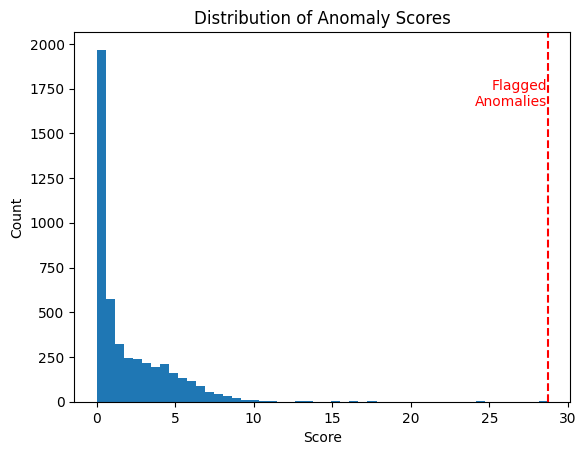

In [97]:
plt.hist(df['anomaly_score'], bins=50)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Score')
plt.ylabel('Count')
threshold = flagged_df["anomaly_score"].max()
plt.text(threshold-0.02, plt.ylim()[1]*0.8, 'Flagged\nAnomalies', color='red', ha='right')
plt.axvline(threshold, color='red', linestyle='--')
plt.show()

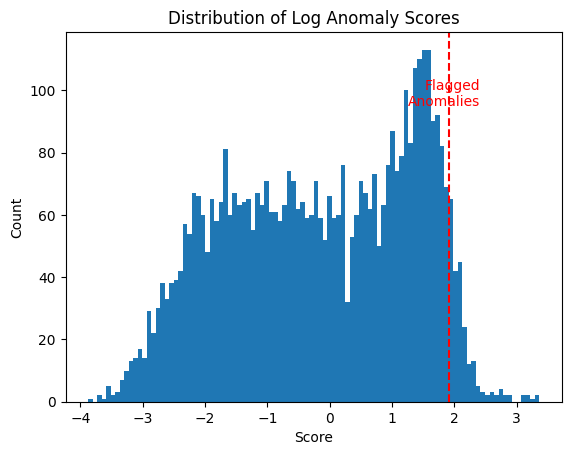

In [98]:
df["log_anomaly_score"] = np.log(df["anomaly_score"])

import numpy as np
plt.hist(df['log_anomaly_score'], bins=100)
plt.title('Distribution of Log Anomaly Scores')
plt.xlabel('Score')
plt.ylabel('Count')
threshold = df.loc[df["anomaly_label"] == -1, "log_anomaly_score"].min()
plt.text(threshold+0.5, plt.ylim()[1]*0.8, 'Flagged\nAnomalies', color='red', ha='right')
plt.axvline(threshold, color='red', linestyle='--')
plt.show()

In [99]:
for i in [1, 5, 15, 30]:
    t_stat, p_value = ttest_ind(
        flagged_df[f"directional_returns_after_{i}d"], 
        normal_df[f"directional_returns_after_{i}d"], 
        equal_var=False
    )
    print(f'Returns after {i} days: {t_stat=}, {p_value=}')

Returns after 1 days: t_stat=np.float64(2.252680224355736), p_value=np.float64(0.02503469623134862)
Returns after 5 days: t_stat=np.float64(1.4808534094405126), p_value=np.float64(0.13985692444546421)
Returns after 15 days: t_stat=np.float64(0.26757790611505483), p_value=np.float64(0.7892381072286166)
Returns after 30 days: t_stat=np.float64(-0.5265077321814806), p_value=np.float64(0.598978395028908)


In [100]:
for i in [5, 15, 30]:
    t_stat, p_value = ttest_ind(
        flagged_df[f"adtv_after_{i}d"], 
        normal_df[f"adtv_after_{i}d"], 
        equal_var=False
    )
    print(f'ADTV after {i} days: {t_stat=}, {p_value=}')

ADTV after 5 days: t_stat=np.float64(-0.09190119927439999), p_value=np.float64(0.926848109748716)
ADTV after 15 days: t_stat=np.float64(0.32558742117973455), p_value=np.float64(0.7450011693956037)
ADTV after 30 days: t_stat=np.float64(0.09822358329299337), p_value=np.float64(0.9218302738115531)


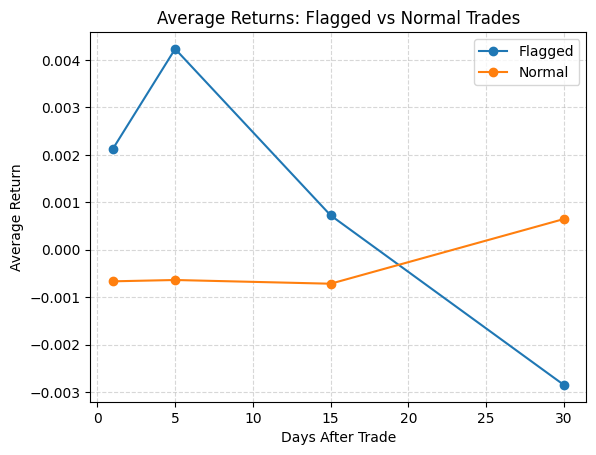

In [101]:
horizons = [1, 5, 15, 30]
flagged_means = []
normal_means = []

for h in horizons:
    flagged_means.append(df.loc[df["anomaly_label"] == -1, f'directional_returns_after_{h}d'].mean())
    normal_means.append(df.loc[df["anomaly_label"] == 1, f'directional_returns_after_{h}d'].mean())

plt.plot(horizons, flagged_means, marker='o', label='Flagged')
plt.plot(horizons, normal_means, marker='o', label='Normal')
plt.xlabel('Days After Trade')
plt.ylabel('Average Return')
plt.title('Average Returns: Flagged vs Normal Trades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

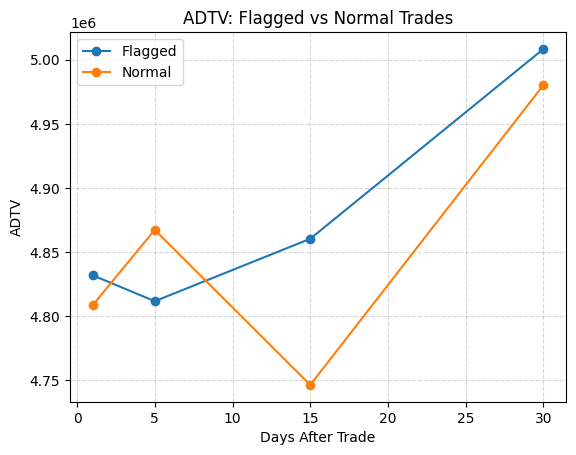

In [102]:
horizons = [1, 5, 15, 30]
flagged_means = []
normal_means = []

for h in horizons:
    flagged_means.append(df.loc[df["anomaly_label"] == -1, f'adtv_after_{h}d'].mean())
    normal_means.append(df.loc[df["anomaly_label"] == 1, f'adtv_after_{h}d'].mean())

plt.plot(horizons, flagged_means, marker='o', label='Flagged')
plt.plot(horizons, normal_means, marker='o', label='Normal')
plt.xlabel('Days After Trade')
plt.ylabel('ADTV')
plt.title('ADTV: Flagged vs Normal Trades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Text(0.5, 1.0, '30-Day Return Distribution')

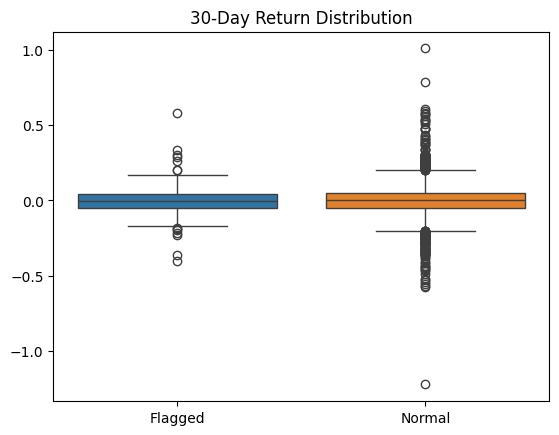

In [103]:
plot_df = pd.concat(
    [
        flagged_df["directional_returns_after_30d"], 
        normal_df["directional_returns_after_30d"]
    ], 
    ignore_index=True,
    axis=1
)

sns.boxplot(data=plot_df)

plt.xticks([0, 1], ['Flagged', 'Normal'])
plt.title('30-Day Return Distribution')

In [104]:
df.loc[df["anomaly_label"] == -1, "directional_returns_after_30d"].mean()

np.float64(-0.0028505911234838234)

In [105]:
df.loc[df["anomaly_label"] == 1, "directional_returns_after_30d"].mean()

np.float64(0.0006460825059093953)

In [106]:
from data.data_utils import load_standardized_feature_set
df = df.join(load_standardized_feature_set(include_known=True)["known_instance"])

Data is cached -- reading /Users/declannelson/Desktop/code/congressional_stock_picks/data/returns_cache/1100f11ed8727b728707f8fd450d7ed8/df.parquet
reading failed tickers


<string>:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


(826 / 1039) tickers are valid


In [107]:
df.sort_values("anomaly_score", ascending=False).head()[["amount", "direction", "directional_returns_after_30d"]]

,,,amount,direction,directional_returns_after_30d
date,senator,ticker,,,
2017-03-24,David Perdue,TRP,40501.0,1.0,0.004128
2018-08-28,Sheldon Whitehouse,LRCX,8000.5,1.0,-0.156002
2020-04-02,Thomas R. Carper,CVS,8000.5,1.0,0.013153
2017-09-08,Shelley Moore Capito,RCL,8000.5,1.0,-0.014757
2018-06-28,David Perdue,BOIVF,8000.5,1.0,-0.038745


In [111]:
df.query("known_instance == 1")[["anomaly_label"]].value_counts()

anomaly_label
 1               112
-1                 4
Name: count, dtype: int64